<a href="https://colab.research.google.com/github/Tavo-Ke/Proyectos-Google-Collab-/blob/main/001Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Entrenando el modelo...
Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 13149.9092 - val_loss: 9488.0400
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6129.2251 - val_loss: 4000.5679
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2304.3838 - val_loss: 1276.2162
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 649.1352 - val_loss: 230.4761
Epoch 5/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 71.3974 - val_loss: 1.5412
Epoch 6/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.0854 - val_loss: 11.0234
Epoch 7/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.7545 - val_loss: 1.8760
Epoch 8/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6252 - val_loss: 1.6622
Epoch 9/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7173 - val_loss: 1.5255
Epoch 10/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5788 - val_loss: 1.4624
Epoch 11/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.5665 - val_loss: 1.4631
Epoch 12/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - lo

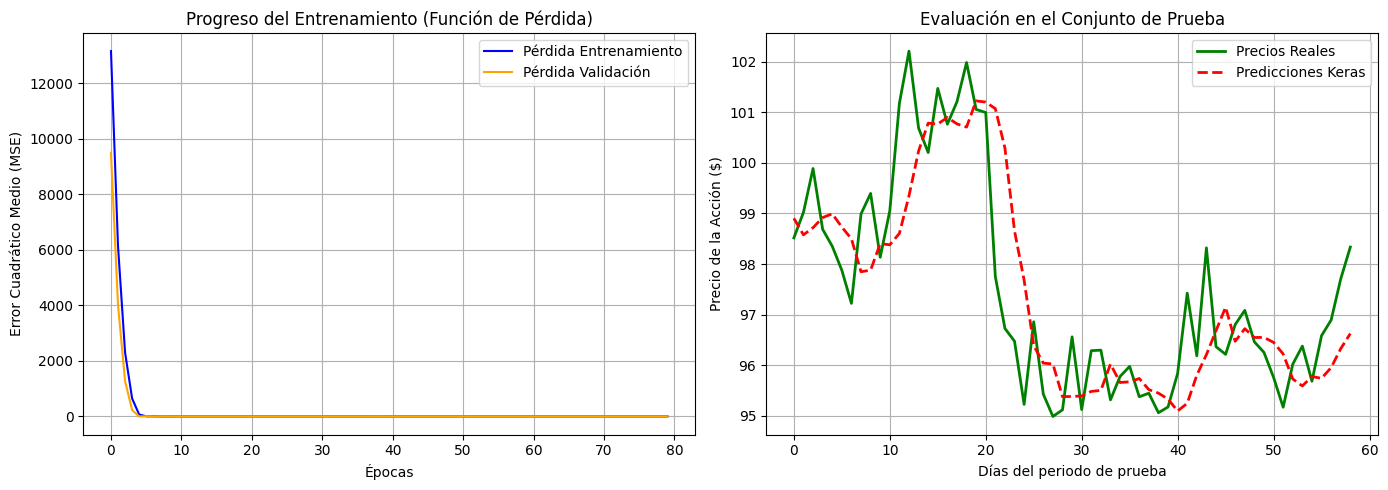

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Generar datos financieros simulados (Serie de tiempo)
np.random.seed(42)
num_dias = 300
# Simulamos una caminata aleatoria para simular el precio de una acción
cambios_diarios = np.random.normal(0, 1, num_dias)
precios = 100 + np.cumsum(cambios_diarios)

# 2. Preparar los datos para el modelo (Ventana de tiempo)
# Usaremos los últimos 5 días (X) para predecir el precio del día siguiente (y)
ventana = 5
X, y = [], []

for i in range(len(precios) - ventana):
    X.append(precios[i : i + ventana])
    y.append(precios[i + ventana])

X = np.array(X)
y = np.array(y)

# Dividir en conjuntos de entrenamiento (80%) y prueba (20%)
limite_division = int(len(X) * 0.8)
X_train, X_test = X[:limite_division], X[limite_division:]
y_train, y_test = y[:limite_division], y[limite_division:]

# 3. Construir la red neuronal con Keras
modelo = Sequential([
    Dense(64, activation='relu', input_shape=(ventana,)),
    Dense(32, activation='relu'),
    Dense(1) # Capa de salida lineal para regresión de precio
])

# Compilar el modelo utilizando el Error Cuadrático Medio (MSE)
modelo.compile(optimizer='adam', loss='mse')

# 4. Entrenar el modelo y guardar el historial para graficar
print("Entrenando el modelo...")
historial = modelo.fit(X_train, y_train, epochs=80, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# 5. Realizar predicciones
predicciones = modelo.predict(X_test)

# ==========================================
# 6. CREACIÓN DE GRÁFICAS
# ==========================================
plt.figure(figsize=(14, 5))

# Gráfica 1: Historial de la Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Pérdida Entrenamiento', color='blue')
plt.plot(historial.history['val_loss'], label='Pérdida Validación', color='orange')
plt.title('Progreso del Entrenamiento (Función de Pérdida)')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)

# Gráfica 2: Comparación de Precios Reales vs Predicciones
plt.subplot(1, 2, 2)
plt.plot(y_test, label='Precios Reales', color='green', linewidth=2)
plt.plot(predicciones, label='Predicciones Keras', color='red', linestyle='--', linewidth=2)
plt.title('Evaluación en el Conjunto de Prueba')
plt.xlabel('Días del periodo de prueba')
plt.ylabel('Precio de la Acción ($)')
plt.legend()
plt.grid(True)

# Mostrar la ventana con las gráficas
plt.tight_layout()
plt.show()


/tmp/ipykernel_1743/3503382022.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start="2022-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - loss: 0.0541 - val_loss: 0.0458
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0080 - val_loss: 0.0103
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0055 - val_loss: 0.0063
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0050 - val_loss: 0.0066
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0050 - val_loss: 0.0071
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0044 - val_loss: 0.0058
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0042 - val_loss: 0.0083
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0039 - val_loss: 0.0050
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0042 - val_loss: 0.0093
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.

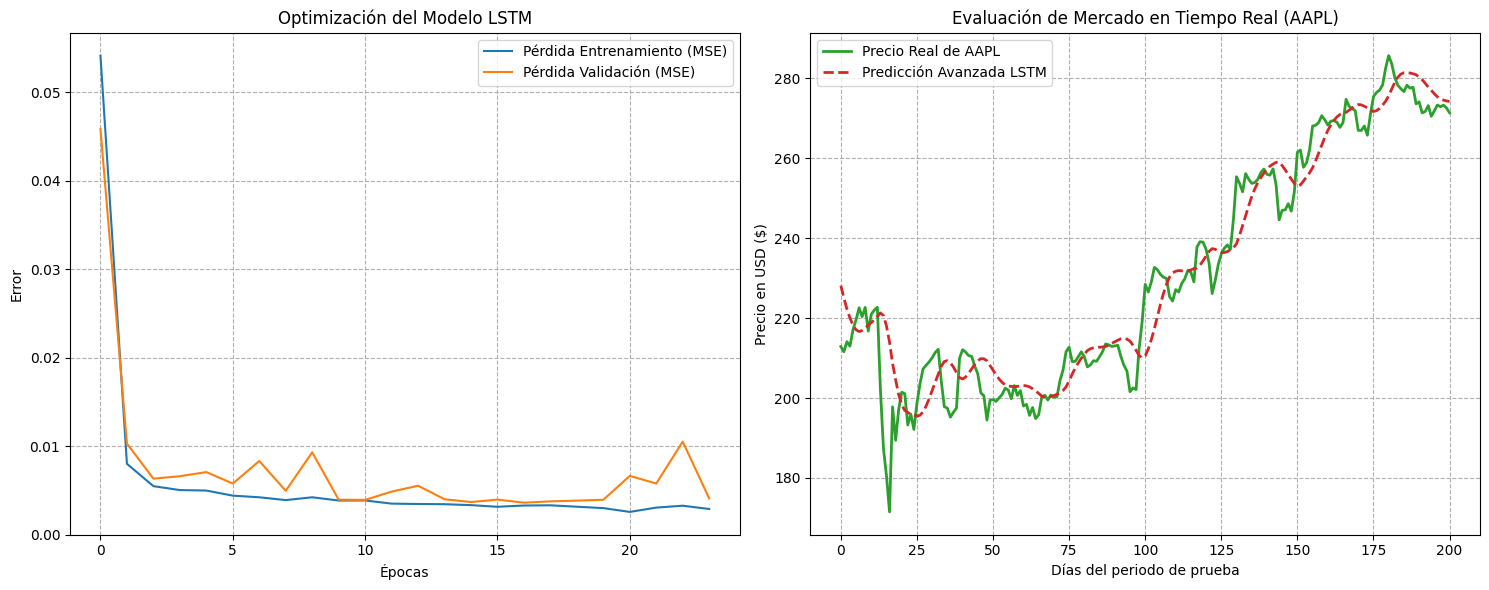

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Descargar datos reales (Apple Inc. - AAPL)
# Usamos un rango de 4 años para tener suficiente historial
ticker = "AAPL"
datos = yf.download(ticker, start="2022-01-01", end="2026-01-01")
precios = datos['Close'].values.reshape(-1, 1)

# 2. División Cronológica (Evita que el futuro altere el pasado)
limite_division = int(len(precios) * 0.8)
datos_entrenamiento = precios[:limite_division]
datos_prueba = precios[limite_division:]

# 3. Escalado Normalizado (Crucial para redes neuronales)
# Ajustamos el escalador SOLO con los datos de entrenamiento para evitar fuga de datos
escalador = MinMaxScaler(feature_range=(0, 1))
entrenamiento_escalado = escalador.fit_transform(datos_entrenamiento)
prueba_escalado = escalador.transform(datos_prueba)

# 4. Crear ventanas temporales dinámicas
# Usaremos los últimos 60 días de bolsa para predecir el día 61
def crear_secuencias(data, ventana=60):
    X, y = [], []
    for i in range(ventana, len(data)):
        X.append(data[i-ventana:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = crear_secuencias(entrenamiento_escalado)
# Para el set de prueba, concatenamos el final del entrenamiento para no perder los primeros 60 días
entradas_prueba = np.vstack((entrenamiento_escalado[-60:], prueba_escalado))
X_test, y_test = crear_secuencias(entradas_prueba)

# Reshaping: LSTM requiere estructura 3D -> [Muestras, Pasos de tiempo, Características]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# 5. Arquitectura de Red Neuronal Recurrente (LSTM)
modelo = Sequential([
    # Primera capa LSTM con Dropout para mitigar el sobreajuste
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    # Segunda capa LSTM (no retorna secuencias porque va a la capa densa)
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    # Capas de salida
    Dense(units=25, activation='relu'),
    Dense(units=1)
])

modelo.compile(optimizer='adam', loss='mean_squared_error')

# 6. Entrenamiento con Parada Temprana (Early Stopping)
# Detiene el entrenamiento si el error de validación deja de mejorar, previniendo sobreajuste
parada_temprana = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

historial = modelo.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[parada_temprana],
    verbose=1
)

# 7. Predicción y Desescalado (Retornar a precios en dólares)
predicciones_escaladas = modelo.predict(X_test)
predicciones = escalador.inverse_transform(predicciones_escaladas)
precios_reales = datos_prueba # Valores originales sin escalar

# ==========================================
# 8. GRÁFICAS DE ALTA RESOLUCIÓN
# ==========================================
plt.figure(figsize=(15, 6))

# Gráfica de Pérdida
plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Pérdida Entrenamiento (MSE)', color='#1f77b4')
plt.plot(historial.history['val_loss'], label='Pérdida Validación (MSE)', color='#ff7f0e')
plt.title('Optimización del Modelo LSTM')
plt.xlabel('Épocas')
plt.ylabel('Error')
plt.legend()
plt.grid(True, linestyle='--')

# Gráfica de Mercado Real vs Predicción
plt.subplot(1, 2, 2)
plt.plot(precios_reales, label=f'Precio Real de {ticker}', color='#2ca02c', linewidth=2)
plt.plot(predicciones, label='Predicción Avanzada LSTM', color='#d62728', linestyle='--', linewidth=2)
plt.title(f'Evaluación de Mercado en Tiempo Real ({ticker})')
plt.xlabel('Días del periodo de prueba')
plt.ylabel('Precio en USD ($)')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# =====================================================================
# 1. DESCARGA Y PREPARACIÓN DE DATOS REALES
# =====================================================================
# Usamos Apple Inc. (AAPL) como activo de prueba con 4 años de historial
ticker = "AAPL"
print(f"Descargando datos históricos para {ticker}...")
datos = yf.download(ticker, start="2022-01-01", end="2026-01-01")
precios = datos['Close'].values.reshape(-1, 1)

# División Cronológica Estricta (80% Entrenamiento, 20% Prueba)
limite_division = int(len(precios) * 0.8)
datos_entrenamiento = precios[:limite_division]
datos_prueba = precios[limite_division:]

# Escalado Normalizado (0 a 1) - Ajustado SOLO con el set de entrenamiento
escalador = MinMaxScaler(feature_range=(0, 1))
entrenamiento_escalado = escalador.fit_transform(datos_entrenamiento)
prueba_escalado = escalador.transform(datos_prueba)

# =====================================================================
# 2. CREACIÓN DE VENTANAS TEMPORALES (LOOKBACK = 60 DÍAS)
# =====================================================================
def crear_secuencias(data, ventana=60):
    X, y = [], []
    for i in range(ventana, len(data)):
        X.append(data[i-ventana:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = crear_secuencias(entrenamiento_escalado)

# Para el set de prueba, incluimos los últimos 60 días de entrenamiento
# para no perder el inicio cronológico de la fase de testeo
entradas_prueba = np.vstack((entrenamiento_escalado[-60:], prueba_escalado))
X_test, y_test = crear_secuencias(entradas_prueba)

# Remodelado a 3D requerido por las capas LSTM: [Muestras, Pasos temporales, Características]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# =====================================================================
# 3. CONSTRUCCIÓN DE LA RED NEURONAL RECURRENTE (LSTM)
# =====================================================================
modelo = Sequential([
    # Primera capa LSTM con Dropout para mitigar el sobreajuste (Overfitting)
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    # Segunda capa LSTM (No retorna secuencias porque conecta a capa Densa)
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    # Capas de inferencia numérica
    Dense(units=25, activation='relu'),
    Dense(units=1)
])

modelo.compile(optimizer='adam', loss='mean_squared_error')

# Configuración de Parada Temprana para frenar el entrenamiento de forma óptima
parada_temprana = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# =====================================================================
# 4. ENTRENAMIENTO DEL MODELO
# =====================================================================
print("\nIniciando el entrenamiento del modelo LSTM...")
historial = modelo.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[parada_temprana],
    verbose=1
)

# =====================================================================
# 5. PREDICCIÓN EN EL CONSET DE PRUEBA Y DESESCALADO
# =====================================================================
predicciones_escaladas = modelo.predict(X_test)
predicciones = escalador.inverse_transform(predicciones_escaladas)
precios_reales = datos_prueba  # Precios originales en USD para contrastar

# =====================================================================
# 6. ALGORITMO AUTORREGRESIVO: PROYECTAR LOS PRÓXIMOS 7 DÍAS AL FUTURO
# =====================================================================
print("\nProyectando los próximos 7 días en el futuro...")
# Tomamos la última ventana conocida del mercado (los últimos 60 días de la prueba)
ultima_ventana = prueba_escalado[-60:]
ventana_actual = ultima_ventana.reshape(1, 60, 1)

predicciones_futuras_escaladas = []

for _ in range(7):
    # Predecir el siguiente paso basado en la ventana móvil actual
    siguiente_pred = modelo.predict(ventana_actual, verbose=0)
    predicciones_futuras_escaladas.append(siguiente_pred)

    # Actualizar la ventana: remueve el día más antiguo [0] e inserta la nueva predicción al final
    nueva_entrada = siguiente_pred.reshape(1, 1, 1)
    ventana_actual = np.append(ventana_actual[:, 1:, :], nueva_entrada, axis=1)

# Transformar las proyecciones de vuelta a la escala original de dólares
predicciones_futuras = escalador.inverse_transform(np.array(predicciones_futuras_escaladas).reshape(-1, 1))

# =====================================================================
# 7. GENERACIÓN DE GRÁFICAS PROFESIONALES
# =====================================================================
plt.figure(figsize=(16, 10))

# --- GRÁFICA 1: Rendimiento del Entrenamiento (Pérdida) ---
plt.subplot(2, 2, 1)
plt.plot(historial.history['loss'], label='Pérdida Entrenamiento (MSE)', color='#1f77b4', linewidth=1.5)
plt.plot(historial.history['val_loss'], label='Pérdida Validación (MSE)', color='#ff7f0e', linewidth=1.5)
plt.title('Optimización de la Red LSTM', fontsize=12, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- GRÁFICA 2: Ajuste del Modelo en el Pasado Reciente ---
plt.subplot(2, 2, 2)
plt.plot(precios_reales, label=f'Precio Real ({ticker})', color='#2ca02c', linewidth=2)
plt.plot(predicciones, label='Ajuste Histórico LSTM', color='#d62728', linestyle='--', linewidth=2)
plt.title('Evaluación de Desempeño en Test Set', fontsize=12, fontweight='bold')
plt.xlabel('Días del Periodo de Prueba')
plt.ylabel('Precio en USD ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- GRÁFICA 3: Extensión con Zoom hacia la Proyección Futura ---
plt.subplot(2, 1, 2)
dias_totales = len(precios_reales)
eje_pasado = np.arange(dias_totales)
eje_futuro = np.arange(dias_totales, dias_totales + 7)

# Graficamos el histórico y añadimos la línea violeta con nodos marcados para los 7 días futuros
plt.plot(eje_pasado[-120:], precios_reales[-120:], label='Historial Real Reciente', color='#2ca02c', linewidth=2)
plt.plot(eje_pasado[-120:], predicciones[-120:], label='Predicción Pasada', color='#d62728', linestyle='--')
plt.plot(eje_futuro, predicciones_futuras, label='Proyección Próximos 7 Días', color='#9467bd', linewidth=3, marker='o', markersize=8)

plt.title(f'Pronóstico Macrotendencial Extrapolado para {ticker}', fontsize=13, fontweight='bold')
plt.xlabel('Línea Temporal (Días)')
plt.ylabel('Precio en USD ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Imprimir el reporte numérico en terminal
print("\n" + "="*50)
print(f" REPORTES DE PROYECCIÓN FUTURA PARA {ticker}")
print("="*50)
for i, precio in enumerate(predicciones_futuras, 1):
    print(f" -> Día de Cierre Futuro +{i}: ${precio[0]:.2f} USD")
print("="*50)


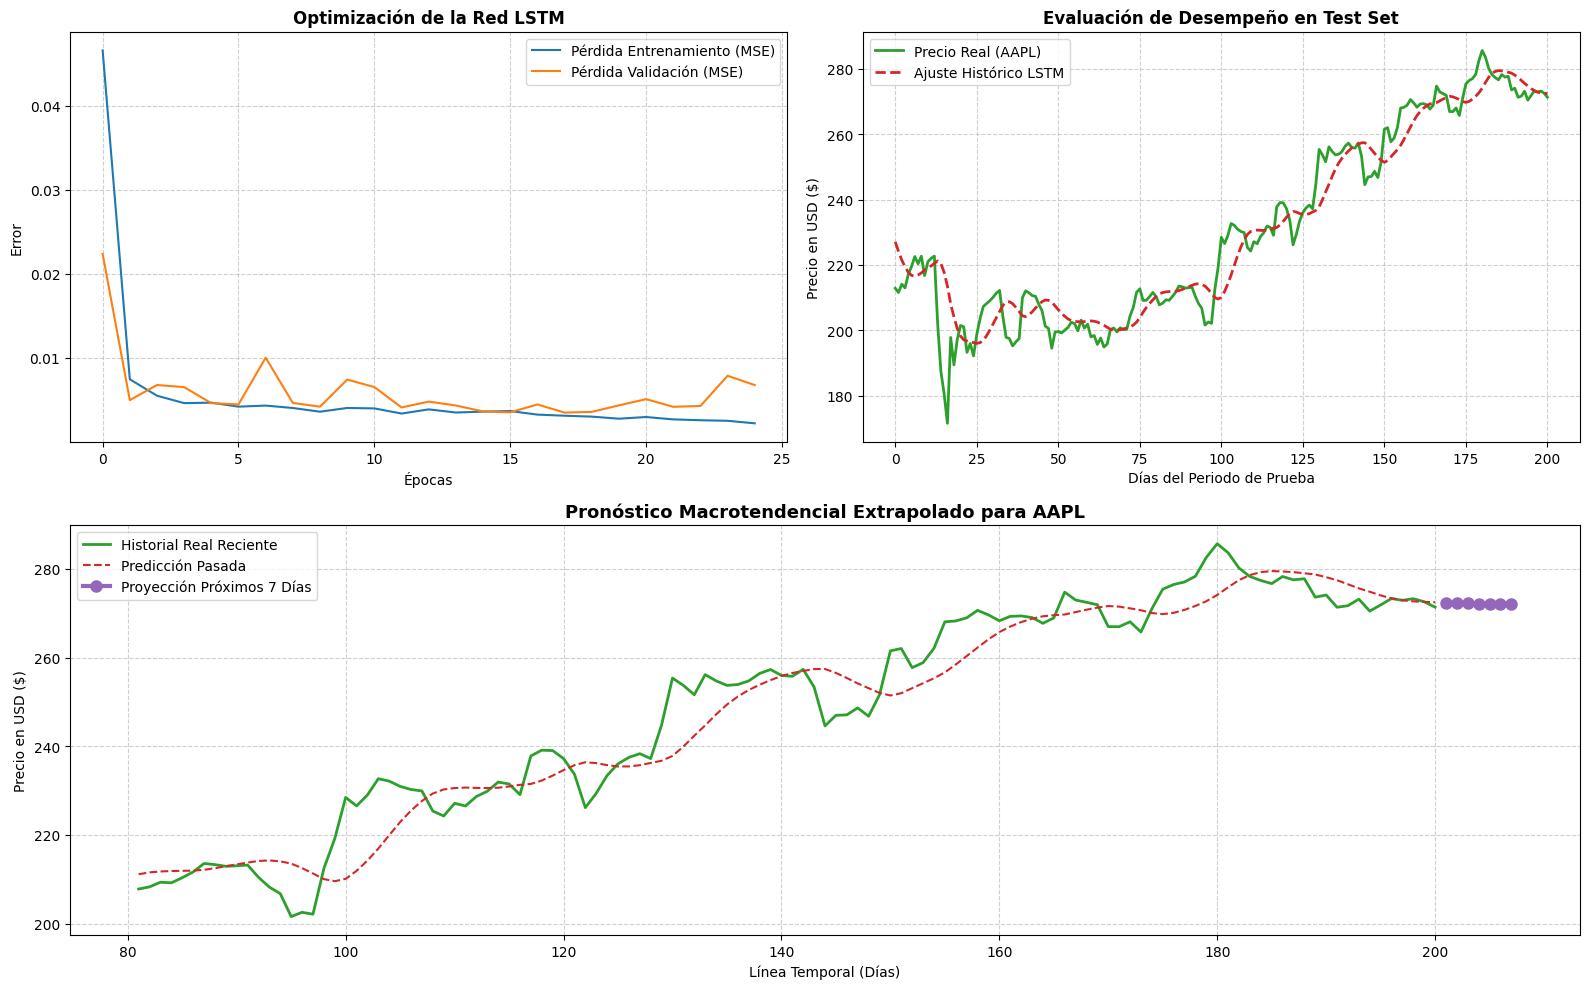

### Evaluación de la Extrapolación Predictiva y Estabilización Asintótica

La proyección autonómica para el horizonte temporal de corto plazo (línea violeta) exhibe un comportamiento de atenuación de varianza que deriva en una estabilización horizontal. En el ámbito del análisis cuantitativo y el modelado de [[Series de Tiempo]], este fenómeno metodológico responde a dos vectores críticos de la dinámica estocástica:

* **Propagación del Error en Bucles [[Modelos Autorregresivos|Autorregresivos]]:** Al ejecutar inferencias iterativas —donde el vector de entrada del tiempo *t+1* se nutre del valor estimado en el tiempo *t*— se genera un efecto de retroalimentación descendente. Este proceso degrada la señal real, acumula las desviaciones típicas del modelo y disipa el *momentum* o inercia tendencial del mercado financiero real.
* **Convergencia Estructural hacia la [[Media Móvil]]:** Ante la ausencia de choques exógenos o flujos de información en tiempo real (volumen, noticias macroeconómicas o microestructura de mercado), la red [[LSTM]] optimiza su función de pérdida eliminando la [[Volatilidad Financiera|volatilidad]]. Consecuentemente, el algoritmo transiciona hacia una función de media móvil adaptativa, convergiendo asintóticamente hacia el valor promedio de la ventana de persistencia histórica (los 60 días previos) para mitigar el [[Error Cuadrático Medio|error cuadrático medio]].

---

### Ontología de Conceptos Relacionados

* **Epistemología del Modelo:** [[Redes Neuronales Recurrentes]] | [[Procesos Estocásticos]] | [[Teorema Central del Límite]]
* **Vulnerabilidades del Sistema:** [[Fuga de Datos]] | [[Overfitting]] | [[Ruido Blanco]]
